# Лабораторна 4. Детекція об’єктів з YOLO
### Шальман Тимофій КА-35

**Мета:** зібрати/підготувати дані у форматі YOLO, навчити щонайменше дві різні архітектури/конфігурації YOLO (наприклад, YOLOv8n vs YOLOv8s, або YOLOv5s vs YOLOv8n; за бажанням додайте YOLOv7‑tiny/YOLOX‑nano) і порівняти якість та швидкість. Оцінити mAP@0.5 і mAP@0.5:0.95, провести інференс на власних зображеннях/відео.

## **Варіант 1:** COCO датасет: підмножина, data.yaml, навчити yolov8n vs yolov8s; порівняти mAP@0.5/0.5:0.95 та FPS.

## Завантаження датасету
[Roboflow: Coco Computer Vision Dataset](https://universe.roboflow.com/yanzhe-xie/coco-n6v8y)

In [1]:
!pip install roboflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.4 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="suYUCWoccL1aGGRqvEqG")
project = rf.workspace("yanzhe-xie").project("coco-n6v8y")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Coco-1 in yolov8:: 100%|██████████| 9991/9991 [00:01<00:00, 6486.34it/s]


In [3]:
!cd Coco-1/ && cat data.yaml

names:
- airplane
- apple
- backpack
- banana
- baseball bat
- baseball glove
- bear
- bed
- bench
- bicycle
- bird
- boat
- book
- bottle
- bowl
- broccoli
- bus
- cake
- car
- carrot
- cat
- cell phone
- chair
- clock
- couch
- cow
- cup
- dining table
- dog
- donut
- elephant
- fire hydrant
- fork
- frisbee
- giraffe
- hair drier
- handbag
- horse
- hot dog
- keyboard
- kite
- knife
- laptop
- microwave
- motorcycle
- mouse
- orange
- oven
- parking meter
- person
- pizza
- potted plant
- refrigerator
- remote
- sandwich
- scissors
- sheep
- sink
- skateboard
- skis
- snowboard
- spoon
- sports ball
- stop sign
- suitcase
- surfboard
- teddy bear
- tennis racket
- tie
- toaster
- toilet
- toothbrush
- traffic light
- train
- truck
- tv
- umbrella
- vase
- wine glass
- zebra
nc: 80
roboflow:
  license: CC BY 4.0
  project: coco-n6v8y
  url: https://universe.roboflow.com/yanzhe-xie/coco-n6v8y/dataset/1
  version: 1
  workspace: yanzhe-xie
test: ../test/images
train: ../train/images
va

## Підготовка моделі

In [4]:
!pip install ultralytics --quiet --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00a 0:00:01


In [5]:
from ultralytics import YOLO
import torch
import time
import cv2
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
data_dir = "/kaggle/working/Coco-1"

## Fine-tuning моделей

## YOLOv8n

In [7]:
model_n = YOLO("yolov8n.pt")

In [8]:
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(torch.cuda.current_device()))

True
0
Tesla T4


In [9]:
results_n = model_n.train(
    data=f"{data_dir}/data.yaml",
    epochs=30,
    imgsz=512,
    batch=16,
    device=0,
    name="yolov8n_exp"
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Coco-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

### Графік mAP@0.5/0.5:0.95

In [10]:
last_yolov8n_exp_dir = "/kaggle/working/runs/detect/yolov8n_exp"

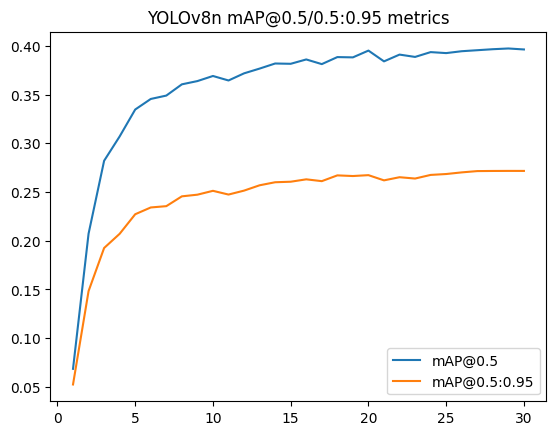

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(f"{last_yolov8n_exp_dir}/results.csv")

plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.legend()
plt.title("YOLOv8n mAP@0.5/0.5:0.95 metrics")
plt.show()

### Приклади роботи моделі

In [12]:
imgs = [
    "/kaggle/working/Coco-1/valid/images/000000000776_jpg.rf.1c5c97407ab77dd05e27633bbbca2268.jpg",
    "/kaggle/working/Coco-1/valid/images/000000001000_jpg.rf.c566d8a80d52373182dae9f647f11a83.jpg",
    "/kaggle/working/Coco-1/valid/images/000000001268_jpg.rf.e02bee8be85922690f2da711389325cb.jpg"
]

results = model_n.predict(
    source=imgs,
    device=0,
    batch=3,
    save=True,
    conf=0.25,
    imgsz=512
)


0: 512x512 4 teddy bears, 14.9ms
1: 512x512 2 handbags, 14 persons, 14.9ms
2: 512x512 1 bird, 2 boats, 2 handbags, 5 persons, 1 suitcase, 14.9ms
Speed: 3.4ms preprocess, 14.9ms inference, 0.9ms postprocess per image at shape (3, 3, 512, 512)
Results saved to /kaggle/working/runs/detect/predict


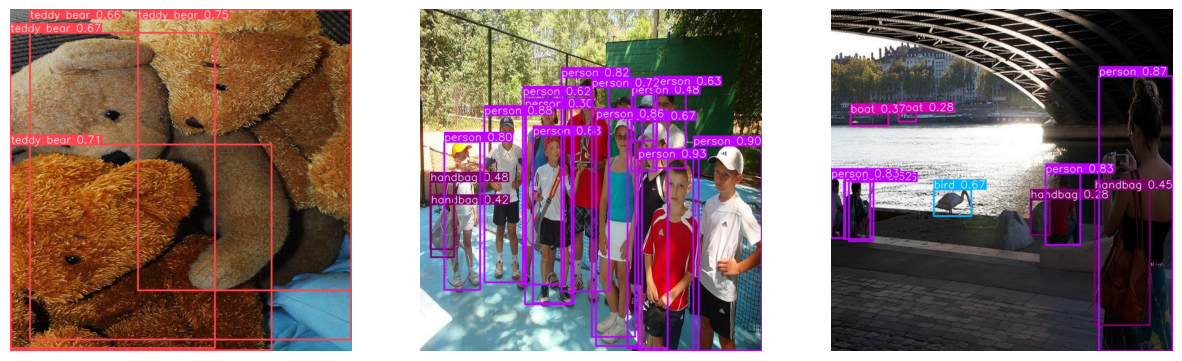

In [14]:
import matplotlib.pyplot as plt

paths = [
    "/kaggle/working/runs/detect/predict/image0.jpg",
    "/kaggle/working/runs/detect/predict/image1.jpg",
    "/kaggle/working/runs/detect/predict/image2.jpg"
]

plt.figure(figsize=(15,5))

for i, p in enumerate(paths):
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

### Кількість параметрів, FLOPs та розмір ваг

In [15]:
model_n.info()

Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


(73, 3151904, 0, 8.746444799999999)

In [16]:
import os

size_mb = os.path.getsize(f"{last_yolov8n_exp_dir}/weights/best.pt") / (1024 * 1024)
print(f"Size: {size_mb:.2f} MB")

Size: 6.22 MB


### FPS/latency (CPU/GPU)
Беру перші 200 зображень з валідаційної вибірки.

In [17]:
import numpy as np
import glob


images = glob.glob(f"{data_dir}/valid/images/*.jpg")
frames = [cv2.imread(p) for p in images[:200]]

# GPU

# warmup
for _ in range(10):
    model_n(frames[0], device=0, verbose=False)

times = []

for frame in frames:
    start = time.time()

    model_n(frame, device=0, verbose=False)

    torch.cuda.synchronize()
    end = time.time()

    times.append(end - start)

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"Avg time: {avg_time:.4f} sec")
print(f"FPS: {fps:.2f}")
print(f"Latency: {avg_time*1000:.2f} ms")

Avg time: 0.0082 sec
FPS: 121.43
Latency: 8.24 ms


In [18]:
# CPU

# warmup
for _ in range(10):
    model_n(frames[0], device="cpu", verbose=False)

times = []

for frame in frames:
    start = time.time()

    model_n(frame, device="cpu", verbose=False)

    end = time.time()

    times.append(end - start)

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"Avg time: {avg_time:.4f} sec")
print(f"FPS: {fps:.2f}")
print(f"Latency: {avg_time*1000:.2f} ms")

Avg time: 0.0647 sec
FPS: 15.47
Latency: 64.66 ms


### Inference на власному фото

In [ ]:
# try:
#   del model_n
# except:
#   pass

# torch.cuda.empty_cache()

In [ ]:
# model_n = YOLO(f"{last_yolov8n_exp_dir}/weights/best.pt")

In [20]:
results = model_n.predict(
    source="/kaggle/input/datasets/ubersober/lab4-uni/test_img.jpg",
    save=True,
    conf=0.25,
    imgsz=512
)

Results saved to /kaggle/working/runs/detect/predict


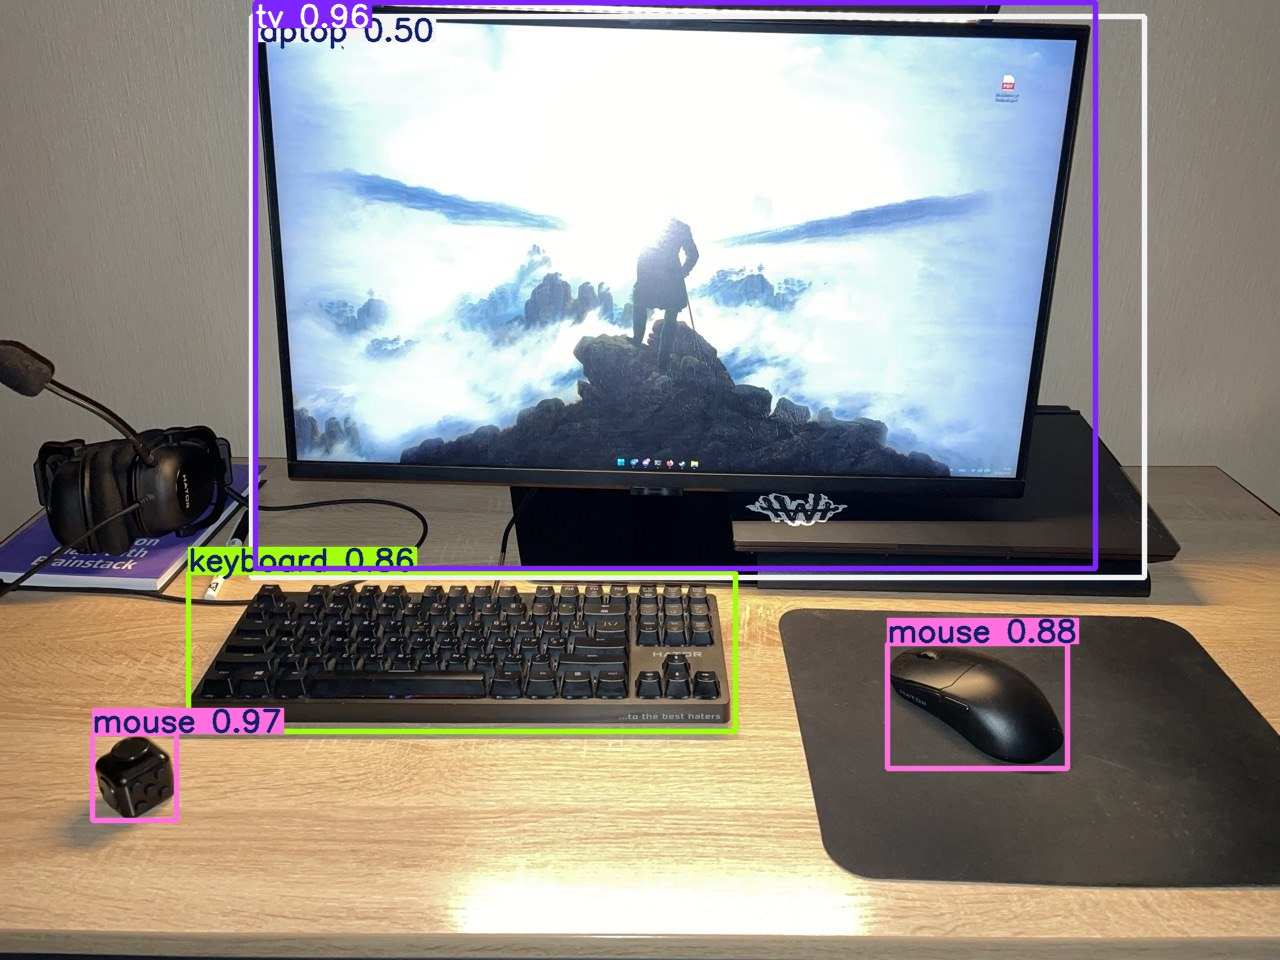

In [21]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/runs/detect/predict/test_img.jpg"))

---
## YOLOv8s

In [22]:
del model_n
torch.cuda.empty_cache()

In [7]:
model_s = YOLO("yolov8s.pt")

In [8]:
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(torch.cuda.current_device()))

True
0
Tesla T4


In [9]:
results_s = model_s.train(
    data=f"{data_dir}/data.yaml",
    epochs=30,
    imgsz=512,
    batch=16,
    device=0,
    name="yolov8s_exp"
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Coco-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

### Графік mAP@0.5/0.5:0.95

In [11]:
last_yolov8s_exp_dir = "/kaggle/working/runs/detect/yolov8s_exp"

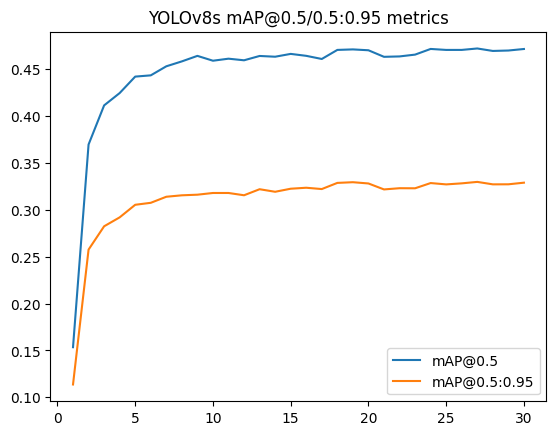

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(f"{last_yolov8s_exp_dir}/results.csv")

plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.legend()
plt.title("YOLOv8s mAP@0.5/0.5:0.95 metrics")
plt.show()

### Приклади роботи моделі

In [14]:
imgs = [
    "/kaggle/working/Coco-1/valid/images/000000000776_jpg.rf.1c5c97407ab77dd05e27633bbbca2268.jpg",
    "/kaggle/working/Coco-1/valid/images/000000001000_jpg.rf.c566d8a80d52373182dae9f647f11a83.jpg",
    "/kaggle/working/Coco-1/valid/images/000000001268_jpg.rf.e02bee8be85922690f2da711389325cb.jpg"
]

results = model_s.predict(
    source=imgs,
    device=0,
    batch=3,
    save=True,
    conf=0.25,
    imgsz=512
)


0: 512x512 3 teddy bears, 15.1ms
1: 512x512 1 handbag, 15 persons, 3 tennis rackets, 15.1ms
2: 512x512 1 bird, 2 boats, 1 cell phone, 3 handbags, 4 persons, 1 umbrella, 15.1ms
Speed: 2.0ms preprocess, 15.1ms inference, 1.0ms postprocess per image at shape (3, 3, 512, 512)
Results saved to /kaggle/working/runs/detect/predict


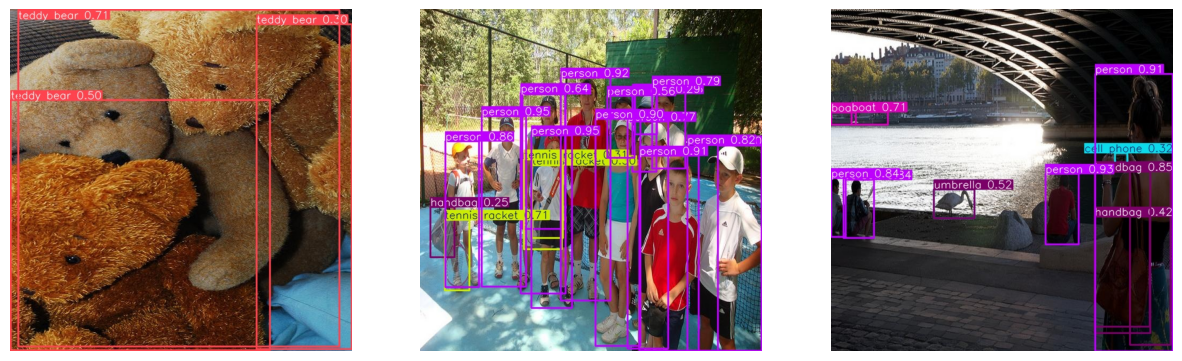

In [15]:
import matplotlib.pyplot as plt

paths = [
    "/kaggle/working/runs/detect/predict/image0.jpg",
    "/kaggle/working/runs/detect/predict/image1.jpg",
    "/kaggle/working/runs/detect/predict/image2.jpg"
]

plt.figure(figsize=(15,5))

for i, p in enumerate(paths):
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

### Кількість параметрів, FLOPs та розмір ваг

In [29]:
model_s.info()

Model summary: 130 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs


(130, 11166560, 0, 28.816844800000002)

In [30]:
import os

size_mb = os.path.getsize(f"{last_yolov8s_exp_dir}/weights/best.pt") / (1024 * 1024)
print(f"Size: {size_mb:.2f} MB")

Size: 21.51 MB


### FPS/latency (CPU/GPU)
Беру перші 200 зображень з валідаційної вибірки.

In [31]:
import numpy as np
import glob


images = glob.glob(f"{data_dir}/valid/images/*.jpg")
frames = [cv2.imread(p) for p in images[:200]]

# GPU

# warmup
for _ in range(10):
    model_s(frames[0], device=0, verbose=False)

times = []

for frame in frames:
    start = time.time()

    model_s(frame, device=0, verbose=False)

    torch.cuda.synchronize()
    end = time.time()

    times.append(end - start)

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"Avg time: {avg_time:.4f} sec")
print(f"FPS: {fps:.2f}")
print(f"Latency: {avg_time*1000:.2f} ms")

Avg time: 0.0086 sec
FPS: 116.26
Latency: 8.60 ms


In [32]:
# CPU

# warmup
for _ in range(10):
    model_s(frames[0], device="cpu", verbose=False)

times = []

for frame in frames:
    start = time.time()

    model_s(frame, device="cpu", verbose=False)

    end = time.time()

    times.append(end - start)

avg_time = np.mean(times)
fps = 1 / avg_time

print(f"Avg time: {avg_time:.4f} sec")
print(f"FPS: {fps:.2f}")
print(f"Latency: {avg_time*1000:.2f} ms")

Avg time: 0.1644 sec
FPS: 6.08
Latency: 164.36 ms


### Inference на власному фото

In [30]:
# try:
#   del model_s
# except:
#   pass

# torch.cuda.empty_cache()

In [24]:
# model_s = YOLO(f"{last_yolov8s_exp_dir}/weights/best.pt")

In [36]:
results = model_s.predict(
    source="/kaggle/input/datasets/ubersober/lab4-uni/test_img.jpg",
    save=True,
    conf=0.25,
    imgsz=512
)

Results saved to /kaggle/working/runs/detect/predict2


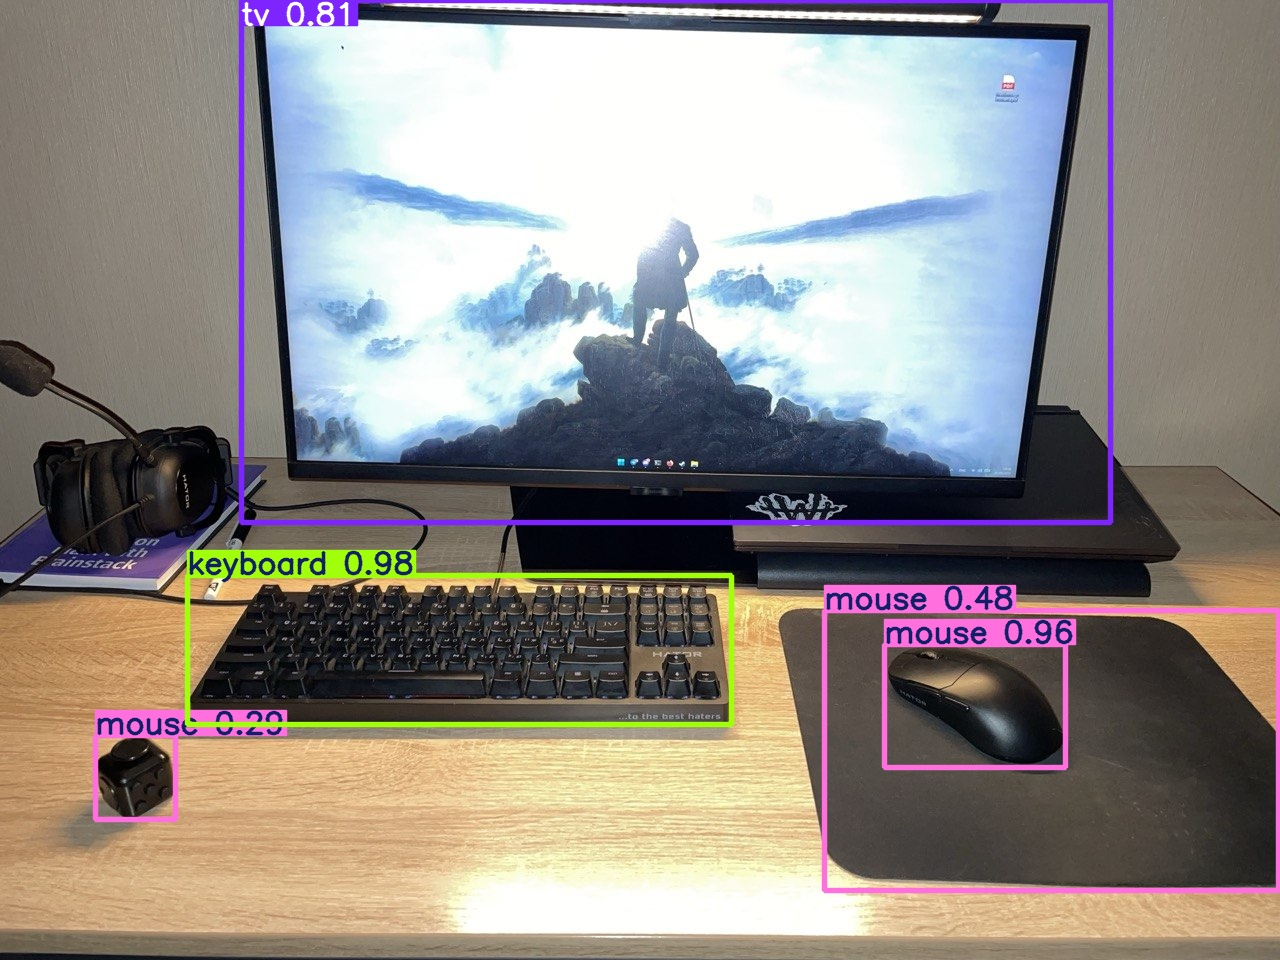

In [37]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/runs/detect/predict2/test_img.jpg"))

## Висновок

### Порівняння моделей YOLOv8n vs YOLOv8s

**GPU: NVIDIA T4 15 GB**

| Модель  | imgsz | Параметри (M) | FLOPs (G) | mAP@0.5 | mAP@0.5:0.95 | FPS (GPU) | FPS (CPU) | Розмір ваг |
|--------|------|--------------|-----------|--------|-------------|-----------|-----------|-----------|
| YOLOv8n | 512  | 3.15         | 8.7       | 0.394  | 0.272       | **121.43**    | **15.47**      | 6.22 MB   |
| YOLOv8s | 512  | **11.17**        | **28.8**     | **0.478**  | **0.331**       | 116.26    | 6.08      | **21.51 MB**  |

`YOLOv8s` демонструє кращу якість детекції (вищі mAP@0.5 та mAP@0.5:0.95) порівняно з `YOLOv8n`, що пояснюється більшою кількістю параметрів і обчислень (~3.5x більше FLOPs).

Водночас `YOLOv8n` значно швидша та легша модель: має менший розмір ваг, вищий FPS на CPU та трохи вищий FPS на GPU. Це робить її більш придатною для real-time застосувань та обмежених ресурсів.

Отже, `YOLOv8n` - кращий вибір для швидких систем (real-time), тоді як `YOLOv8s` - для задач, де важливіша точність.

У інференсі на власному фото `YOLOv8s` відпрацювала якісніше.